# Notebook 3 - Generalization Study: Does the Truth Direction Transfer?

## Goal

A lie detector is only interesting if it generalizes. If a probe trained on one dataset works only on that same dataset, it may have learned superficial dataset artifacts.

This notebook trains a probe on `repeng_truthful` and evaluates it on every available dataset. This is the compact version of the transfer question studied in `repeng`.


## Step 1 - Setup and dataset construction

By default, this notebook uses the local datasets so it can run quickly. Set `INCLUDE_HF_DATASETS=True` to include TruthfulQA, ARC, and BoolQ from Hugging Face.


In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "lie_detector_llm").exists():
            return candidate
    raise RuntimeError("Could not find the project root. Run this notebook from the repository.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/imadsharof/Library/Mobile Documents/com~apple~CloudDocs/Cours/MA1/Computing Project/Lie-Detector-for-LLM


In [2]:
from lie_detector_llm.datasets import build_dataset_collection

INCLUDE_HF_DATASETS = False
MAX_HF_GROUPS = 100

collection = build_dataset_collection(
    include_hf_datasets=INCLUDE_HF_DATASETS,
    max_hf_groups=MAX_HF_GROUPS,
)
dataset_names = collection.dataset_names()

print(f"Datasets: {dataset_names}")
print(f"Total prompts: {len(collection.frame)}")
print(f"Total groups : {collection.frame['group_id'].nunique()}")


Datasets: ['cities', 'larger_than', 'qa', 'repeng_truthful']
Total prompts: 408
Total groups : 144


## Step 2 - Configure the transfer experiment

We train on `repeng_truthful` and evaluate on all datasets.

`split_evaluation=True` is important. It means the probe trains only on the training split of `repeng_truthful`, then evaluates on the test split of each dataset. This avoids reporting training-set accuracy as if it were generalization.


In [3]:
MODEL_NAME = "microsoft/phi-2"
TRAIN_DATASET = "repeng_truthful"
PROBE_METHOD = "lr"
LAYER_INDEX = -1
LOAD_IN_4BIT = False
ACTIVATION_BATCH_SIZE = 2

print("Transfer configuration")
print(f"Model        : {MODEL_NAME}")
print(f"Train data   : {TRAIN_DATASET}")
print(f"Eval data    : {dataset_names}")
print(f"Probe        : {PROBE_METHOD}")
print(f"Layer        : {LAYER_INDEX}")


Transfer configuration
Model        : microsoft/phi-2
Train data   : repeng_truthful
Eval data    : ['cities', 'larger_than', 'qa', 'repeng_truthful']
Probe        : lr
Layer        : -1


## Step 3 - Run one-to-many transfer

The output table has one row per evaluation dataset. High off-domain accuracy suggests that the probe has found a more general truthfulness direction rather than a dataset-specific shortcut.


In [4]:
from lie_detector_llm.experiment import run_transfer_experiment

transfer_result = run_transfer_experiment(
    collection=collection,
    train_dataset_name=TRAIN_DATASET,
    eval_dataset_names=dataset_names,
    model_name=MODEL_NAME,
    probe_method=PROBE_METHOD,
    layer_index=LAYER_INDEX,
    split_evaluation=True,
    activation_batch_size=ACTIVATION_BATCH_SIZE,
    load_in_4bit=LOAD_IN_4BIT,
    show_progress=True,
)

transfer_table = transfer_result.summary_table().sort_values("eval_dataset")
display(transfer_table)


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

Extracting activations:   0%|          | 0/73 [00:00<?, ?it/s]

,train_dataset,eval_dataset,probe_method,model_name,layer_index,split_evaluation,eval_split,grouped_accuracy
0,repeng_truthful,cities,lr,microsoft/phi-2,-1,True,test,0.833333
1,repeng_truthful,larger_than,lr,microsoft/phi-2,-1,True,test,0.833333
2,repeng_truthful,qa,lr,microsoft/phi-2,-1,True,test,0.666667
3,repeng_truthful,repeng_truthful,lr,microsoft/phi-2,-1,True,test,1.000000


## Step 4 - Plot transfer accuracy

The plot shows grouped accuracy for each evaluation dataset. The most important bars are the off-domain datasets, because they measure transfer.


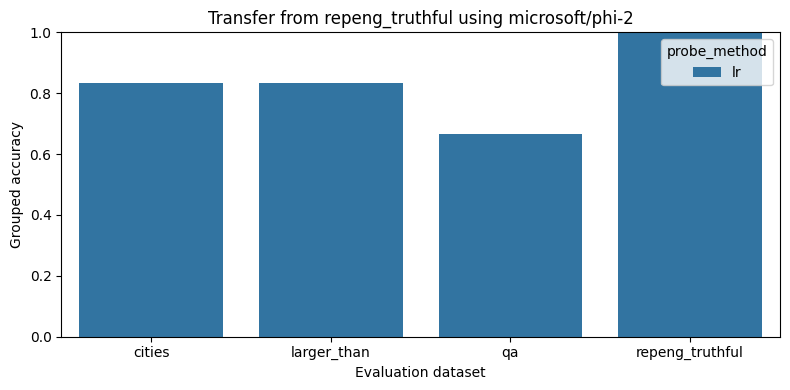

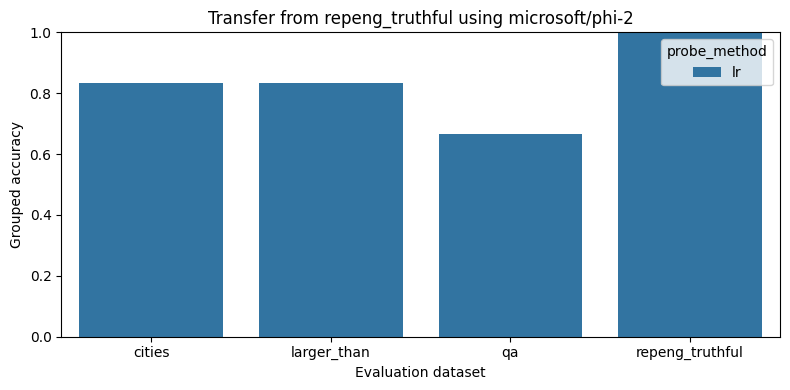

In [5]:
from lie_detector_llm.plotting import plot_transfer_results

fig, ax = plot_transfer_results(
    transfer_result.results,
    title=f"Transfer from {TRAIN_DATASET} using {MODEL_NAME}",
)
fig


## Step 5 - Compare probe methods under transfer

A supervised probe such as logistic regression may fit the train dataset well but transfer poorly. Simpler direction-based probes can sometimes transfer better.

The next cell repeats the same transfer experiment for all probe methods.


In [6]:
import pandas as pd

all_transfer_rows = []
for method in ["dim", "lat", "lr", "pca-g"]:
    out = run_transfer_experiment(
        collection=collection,
        train_dataset_name=TRAIN_DATASET,
        eval_dataset_names=dataset_names,
        model_name=MODEL_NAME,
        probe_method=method,
        layer_index=LAYER_INDEX,
        split_evaluation=True,
        activation_batch_size=ACTIVATION_BATCH_SIZE,
        load_in_4bit=LOAD_IN_4BIT,
        show_progress=True,
    )
    all_transfer_rows.append(out.summary_table())

all_transfer = pd.concat(all_transfer_rows, ignore_index=True)
display(all_transfer.sort_values(["probe_method", "eval_dataset"]))


Extracting activations:   0%|          | 0/73 [00:00<?, ?it/s]

Extracting activations:   0%|          | 0/73 [00:00<?, ?it/s]

Extracting activations:   0%|          | 0/73 [00:00<?, ?it/s]

Extracting activations:   0%|          | 0/73 [00:00<?, ?it/s]

,train_dataset,eval_dataset,probe_method,model_name,layer_index,split_evaluation,eval_split,grouped_accuracy
0,repeng_truthful,cities,dim,microsoft/phi-2,-1,True,test,0.833333
1,repeng_truthful,larger_than,dim,microsoft/phi-2,-1,True,test,0.833333
2,repeng_truthful,qa,dim,microsoft/phi-2,-1,True,test,0.666667
3,repeng_truthful,repeng_truthful,dim,microsoft/phi-2,-1,True,test,0.545455
4,repeng_truthful,cities,lat,microsoft/phi-2,-1,True,test,0.500000
5,repeng_truthful,larger_than,lat,microsoft/phi-2,-1,True,test,0.833333
6,repeng_truthful,qa,lat,microsoft/phi-2,-1,True,test,0.500000
7,repeng_truthful,repeng_truthful,lat,microsoft/phi-2,-1,True,test,0.272727
8,repeng_truthful,cities,lr,microsoft/phi-2,-1,True,test,0.833333
9,repeng_truthful,larger_than,lr,microsoft/phi-2,-1,True,test,0.833333


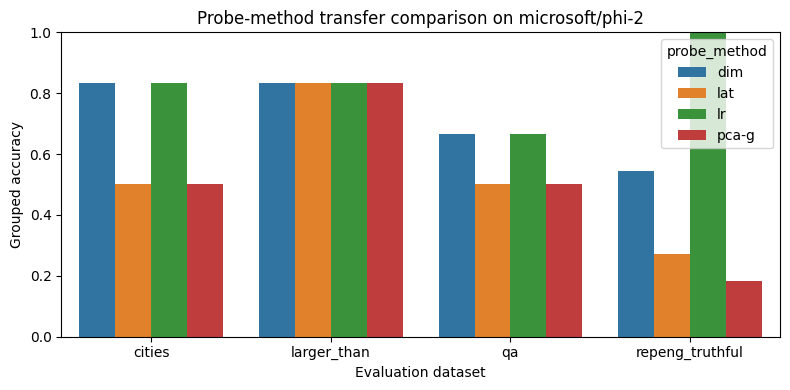

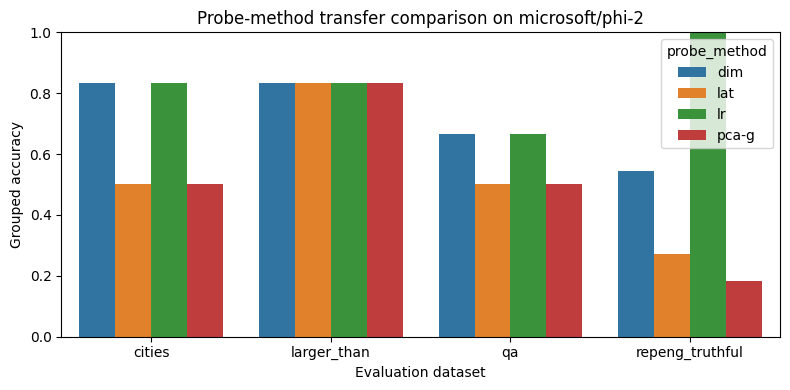

In [7]:
fig, ax = plot_transfer_results(
    all_transfer,
    title=f"Probe-method transfer comparison on {MODEL_NAME}",
)
fig


## Interpretation checklist

Use these questions when writing the report:

- Which probe performs best on the source dataset?
- Which probe transfers best to other datasets?
- Are the best in-distribution and best transfer probes the same?
- Are some datasets systematically harder than others?

The professor's request for comparisons between LLMs should use the same logic, but repeat this table for several models. That is exactly what Notebook 6 does.
